# Early Stunting Risk Prediction
## Machine Learning Pipeline

---

### Project Overview

Notebook ini membangun keseluruhan pipeline Machine Learning untuk proyek **Early Stunting Risk AI** menggunakan dataset sintetis yang telah dibuat pada Phase 2.

Pipeline dirancang agar:

- Reproducible
- Modular
- Production Ready
- Backend Friendly
- Explainable AI Ready

Notebook ini akan menghasilkan model terbaik beserta seluruh artifact yang diperlukan oleh backend FastAPI tanpa perlu melakukan preprocessing secara manual.

---

## Objectives

Tahapan utama notebook meliputi:

1. Load Dataset
2. Initial Data Checking
3. Exploratory Data Analysis
4. Preprocessing Pipeline
5. Model Training
6. Cross Validation
7. Hyperparameter Tuning
8. Final Evaluation
9. Model Interpretation Preparation
10. Save Artifacts
11. Backend Compatibility Check

---

## Dataset

Dataset yang digunakan:

- train.csv
- validation.csv
- test.csv

Target Classification:

- risk_level

Dataset berasal dari generator sintetis yang dibangun berdasarkan hubungan antar faktor risiko stunting yang realistis.

---

## Output

Notebook akan menghasilkan:

```
model/
│
├── trained_models/
│ └── best_pipeline.pkl
│
├── artifacts/
│ ├── feature_names.json
│ ├── training_config.json
│ └── label_mapping.json
│
├── metrics/
│ ├── metrics.json
│ ├── classification_report.json
│ ├── cross_validation.json
│ └── model_info.json
│
└── figures/
├── confusion_matrix.png
├── roc_curve.png
├── precision_recall_curve.png
└── feature_importance.png
```

In [1]:
# IMPORT LIBRARIES

from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Cross Validation
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

# Candidate Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

plt.style.use("default")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# PROJECT CONFIGURATION
RANDOM_STATE = 42

TARGET_COLUMN = "risk_level"

N_SPLITS = 5

SCORING = "f1_weighted"

# DATA PATH
DATA_DIR = Path("/kaggle/input/datasets/hamzbriel/early-stunting-risk-prediction-dataset")

TRAIN_PATH = DATA_DIR / "train.csv"
VALID_PATH = DATA_DIR / "validation.csv"
TEST_PATH = DATA_DIR / "test.csv"

# OUTPUT PATH
MODEL_DIR = Path("/kaggle/working/model")

TRAINED_MODEL_DIR = MODEL_DIR / "trained_models"
ARTIFACT_DIR = MODEL_DIR / "artifacts"
METRIC_DIR = MODEL_DIR / "metrics"
FIGURE_DIR = MODEL_DIR / "figures"

# CREATE OUTPUT DIRECTORY
TRAINED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration Loaded")

Configuration Loaded


In [8]:
# LOAD DATASET
train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset Loaded Successfully\n")

print(f"Train      : {train_df.shape}")
print(f"Validation : {valid_df.shape}")
print(f"Test       : {test_df.shape}")

Dataset Loaded Successfully

Train      : (7000, 22)
Validation : (1500, 22)
Test       : (1500, 22)


In [9]:
display(train_df.head())

,age_month,gender,birth_weight,birth_length,mother_age,mother_education,mother_working,father_education,father_working,family_income,...,electricity,house_density,exclusive_breastfeeding,protein_intake,vitamin_intake,immunization,diarrhea_history,healthcare_access,risk_score,risk_level
0,29,M,2.86,49.7,27.0,secondary,1,secondary,1.0,high,...,1,low,1.0,low,high,complete,0,good,26.78,Low
1,29,F,2.82,48.8,29.0,higher,1,higher,1.0,medium,...,1,low,1.0,high,high,partial,0,fair,27.85,Low
2,15,M,3.01,48.4,31.0,secondary,1,secondary,1.0,medium,...,1,high,0.0,high,medium,complete,0,good,33.08,Low
3,54,M,2.10,43.7,28.0,secondary,0,secondary,1.0,low,...,1,medium,1.0,low,medium,none,0,poor,74.78,High
4,55,M,2.91,48.7,26.0,secondary,1,secondary,1.0,very_low,...,1,high,0.0,low,medium,none,0,poor,64.94,Medium


In [10]:
# DATASET INFORMATION

print("="*60)
print("TRAIN")
print("="*60)

train_df.info()

print("\n")

print("="*60)
print("VALIDATION")
print("="*60)

valid_df.info()

print("\n")

print("="*60)
print("TEST")
print("="*60)

test_df.info()

TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_month                7000 non-null   int64  
 1   gender                   7000 non-null   object 
 2   birth_weight             7000 non-null   float64
 3   birth_length             7000 non-null   float64
 4   mother_age               6940 non-null   float64
 5   mother_education         7000 non-null   object 
 6   mother_working           7000 non-null   int64  
 7   father_education         7000 non-null   object 
 8   father_working           6931 non-null   float64
 9   family_income            7000 non-null   object 
 10  sanitation               6948 non-null   object 
 11  clean_water              7000 non-null   int64  
 12  electricity              7000 non-null   int64  
 13  house_density            7000 non-null   object 
 14  exclusive_breastfe

In [11]:
display(train_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_month,7000.0,NaN,NaN,NaN,29.513286,17.243625,0.0,15.0,29.0,44.0,59.0
gender,7000,2,M,3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_weight,7000.0,NaN,NaN,NaN,3.11274,0.450419,1.5,2.81,3.11,3.41,4.67
birth_length,7000.0,NaN,NaN,NaN,49.470657,2.501275,40.6,47.8,49.4,51.1,59.9
mother_age,6940.0,NaN,NaN,NaN,28.021902,5.922138,15.0,24.0,28.0,32.0,50.0
mother_education,7000,4,secondary,2808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mother_working,7000.0,NaN,NaN,NaN,0.446857,0.497203,0.0,0.0,0.0,1.0,1.0
father_education,7000,4,secondary,3001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
father_working,6931.0,NaN,NaN,NaN,0.849228,0.357852,0.0,1.0,1.0,1.0,1.0
family_income,7000,4,medium,3113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Initial Data Checking

Tahap ini bertujuan memastikan kualitas dataset sebelum dilakukan preprocessing.

Pemeriksaan meliputi:

- Dimensi dataset
- Tipe data
- Missing value
- Duplicate data
- Distribusi target
- Konsistensi struktur antar dataset

In [12]:
# DATASET SHAPE
summary = pd.DataFrame({
    "Dataset":["Train","Validation","Test"],
    "Rows":[len(train_df),len(valid_df),len(test_df)],
    "Columns":[train_df.shape[1],valid_df.shape[1],test_df.shape[1]]
})

display(summary)

,Dataset,Rows,Columns
0,Train,7000,22
1,Validation,1500,22
2,Test,1500,22


In [13]:
# COLUMN CONSISTENCY CHECK

assert list(train_df.columns) == list(valid_df.columns)
assert list(train_df.columns) == list(test_df.columns)

print("All datasets have identical columns.")

All datasets have identical columns.


In [14]:
# MISSING VALUE CHECK
missing = (
    train_df
    .isna()
    .sum()
    .to_frame("Missing Count")
)

missing["Missing Percentage"] = (
    missing["Missing Count"] /
    len(train_df)
    *100
)

display(
    missing.sort_values(
        "Missing Count",
        ascending=False
    )
)

,Missing Count,Missing Percentage
protein_intake,73,1.042857
father_working,69,0.985714
mother_age,60,0.857143
exclusive_breastfeeding,59,0.842857
sanitation,52,0.742857
age_month,0,0.000000
mother_education,0,0.000000
birth_length,0,0.000000
birth_weight,0,0.000000
gender,0,0.000000


In [15]:
# DUPLICATE CHECK
duplicates = train_df.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 0


# Feature & Target Separation

Tahap ini menentukan:

- Target klasifikasi
- Feature yang digunakan
- Feature yang dikeluarkan
- Pemeriksaan data leakage

Target utama:

- risk_level

Feature yang tidak digunakan:

- risk_score (mencegah target leakage)

In [16]:
# TARGET CONFIGURATION
TARGET_COLUMN = "risk_level"

DROP_COLUMNS = [
    "risk_score",
    TARGET_COLUMN
]

print("Target :", TARGET_COLUMN)
print("Dropped :", DROP_COLUMNS)

Target : risk_level
Dropped : ['risk_score', 'risk_level']


In [17]:
# FEATURE & TARGET SEPARATION

X_train = train_df.drop(columns=DROP_COLUMNS)

y_train = train_df[TARGET_COLUMN]

X_valid = valid_df.drop(columns=DROP_COLUMNS)

y_valid = valid_df[TARGET_COLUMN]

X_test = test_df.drop(columns=DROP_COLUMNS)

y_test = test_df[TARGET_COLUMN]

print("Train Feature :", X_train.shape)
print("Train Target  :", y_train.shape)

Train Feature : (7000, 20)
Train Target  : (7000,)


In [18]:
# FEATURE LIST

feature_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Data Type": X_train.dtypes.astype(str)
})

display(feature_df)

,Feature,Data Type
age_month,age_month,int64
gender,gender,object
birth_weight,birth_weight,float64
birth_length,birth_length,float64
mother_age,mother_age,float64
mother_education,mother_education,object
mother_working,mother_working,int64
father_education,father_education,object
father_working,father_working,float64
family_income,family_income,object


In [19]:
# FEATURE TYPE DETECTION

numerical_features = (
    X_train
    .select_dtypes(include=["int64","float64"])
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include=["object","category","bool"])
    .columns
    .tolist()
)

print("Numerical Feature")
print("-----------------")
print(numerical_features)

print()

print("Categorical Feature")
print("-------------------")
print(categorical_features)

Numerical Feature
-----------------
['age_month', 'birth_weight', 'birth_length', 'mother_age', 'mother_working', 'father_working', 'clean_water', 'electricity', 'exclusive_breastfeeding', 'diarrhea_history']

Categorical Feature
-------------------
['gender', 'mother_education', 'father_education', 'family_income', 'sanitation', 'house_density', 'protein_intake', 'vitamin_intake', 'immunization', 'healthcare_access']


In [20]:
# FEATURE SUMMARY

summary = pd.DataFrame({

    "Feature Type":[
        "Numerical",
        "Categorical"
    ],

    "Count":[
        len(numerical_features),
        len(categorical_features)
    ]

})

display(summary)

,Feature Type,Count
0,Numerical,10
1,Categorical,10


# Preprocessing Design

Pipeline preprocessing dirancang agar:

- dapat digunakan kembali
- dapat disimpan menggunakan joblib
- kompatibel dengan FastAPI
- tidak memerlukan preprocessing manual saat inferensi

Preprocessing dilakukan menggunakan `ColumnTransformer`.

In [21]:
# NUMERICAL PREPROCESSOR

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [22]:
# CATEGORICAL PREPROCESSOR

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [36]:
# COLUMN TRANSFORMER

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ],

    remainder="drop"

)
preprocessor.set_output(transform="pandas")
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_month', 'birth_weight', 'birth_length',
                                  'mother_age', 'mother_working',
                                  'father_working', 'clean_water',
                                  'electricity', 'exclusive_breastfeeding',
                                  'diarrhea_history']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'mother_education',
                                  'father_education', 'family_income',
                                  'sanitation', 'house_density',
                                  'protein_intake', 'vitamin_intake',
                                  'immunization', 'healthcare_access'])])

In [37]:
# FIT PREPROCESSOR

X_train_processed = preprocessor.fit_transform(X_train)

print("Original Shape :", X_train.shape)

print("Processed Shape :", X_train_processed.shape)

Original Shape : (7000, 20)
Processed Shape : (7000, 42)


In [38]:
# FEATURE NAMES AFTER PREPROCESSING

feature_names = preprocessor.get_feature_names_out()

print("Total Feature After Encoding :")

print(len(feature_names))

feature_names[:20]

Total Feature After Encoding :
42


array(['num__age_month', 'num__birth_weight', 'num__birth_length',
       'num__mother_age', 'num__mother_working', 'num__father_working',
       'num__clean_water', 'num__electricity',
       'num__exclusive_breastfeeding', 'num__diarrhea_history',
       'cat__gender_F', 'cat__gender_M', 'cat__mother_education_higher',
       'cat__mother_education_none', 'cat__mother_education_primary',
       'cat__mother_education_secondary', 'cat__father_education_higher',
       'cat__father_education_none', 'cat__father_education_primary',
       'cat__father_education_secondary'], dtype=object)

In [39]:
# FEATURE NAME DATAFRAME

feature_name_df = pd.DataFrame({
    "Feature": feature_names
})

display(feature_name_df.head(20))

,Feature
0,num__age_month
1,num__birth_weight
2,num__birth_length
3,num__mother_age
4,num__mother_working
5,num__father_working
6,num__clean_water
7,num__electricity
8,num__exclusive_breastfeeding
9,num__diarrhea_history


In [40]:
# VALIDATION AFTER PREPROCESSING

processed_df = pd.DataFrame(

    X_train_processed,

    columns=feature_names

)

print("Missing Value :", processed_df.isna().sum().sum())

print("Duplicated :", processed_df.duplicated().sum())

print("Processed Shape :", processed_df.shape)

Missing Value : 0
Duplicated : 0
Processed Shape : (7000, 42)


# Machine Learning Pipeline

Seluruh model akan menggunakan preprocessing yang sama.

Pipeline terdiri dari:

Raw Feature --> ColumnTransformer --> Machine Learning Model

Dengan pendekatan ini, backend hanya perlu memanggil:

pipeline.predict()

pipeline.predict_proba()

tanpa preprocessing tambahan.

In [41]:
# BUILD PIPELINE

def build_pipeline(model):
    """
    Build complete preprocessing + model pipeline.
    """

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    return pipeline

# Candidate Models

Model yang akan dibandingkan:

- Logistic Regression
- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

Seluruh model menggunakan preprocessing yang identik sehingga perbandingan menjadi adil.

In [42]:
# CANDIDATE MODELS

models = {

    "Logistic Regression":
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=RANDOM_STATE
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            random_state=RANDOM_STATE
        ),

    "XGBoost":
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="mlogloss"
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1
        ),

    "CatBoost":
        CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0
        )

}

In [43]:
# LABEL ENCODING

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)

print("Class Mapping")

for idx, label in enumerate(label_encoder.classes_):
    print(f"{idx} -> {label}")

Class Mapping
0 -> High
1 -> Low
2 -> Medium


In [44]:
# LABEL MAPPING

label_mapping = {
    int(i): str(label)
    for i, label in enumerate(label_encoder.classes_)
}

label_mapping

{0: 'High', 1: 'Low', 2: 'Medium'}

# Cross Validation

Evaluasi awal dilakukan menggunakan Stratified K-Fold Cross Validation.

Tujuan:

- membandingkan performa model
- mengurangi bias akibat pembagian data
- memilih kandidat terbaik sebelum tuning

In [45]:
# STRATIFIED K FOLD

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [46]:
# CROSS VALIDATION SCORING
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

In [47]:
# BASELINE CROSS VALIDATION

cv_results = []

for model_name, model in models.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    pipeline = build_pipeline(model)

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {

        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()

    }

    cv_results.append(result)

print("\nCross Validation Finished.")

Logistic Regression
Random Forest
Extra Trees
XGBoost
LightGBM
CatBoost

Cross Validation Finished.


In [48]:
# CROSS VALIDATION RESULT
cv_result_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        by="F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_result_df)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,CatBoost,0.889143,0.005775,0.889245,0.889143,0.888581,0.005507
1,Logistic Regression,0.887857,0.010508,0.888214,0.887857,0.887404,0.010313
2,LightGBM,0.884857,0.003540,0.884829,0.884857,0.884296,0.003248
3,XGBoost,0.882857,0.004760,0.882702,0.882857,0.882403,0.004566
4,Random Forest,0.877000,0.006017,0.878039,0.877000,0.875263,0.006001
5,Extra Trees,0.869429,0.005447,0.869719,0.869429,0.868109,0.005354


In [50]:
# MODEL COMPARISON

fig = px.bar(
    cv_result_df,
    x="Model",
    y="F1 Mean",
    color="F1 Mean",
    text="F1 Mean",
    title="Cross Validation Comparison"
)

fig.update_traces(texttemplate="%{text:.4f}")
fig.show()

In [51]:
# SAVE CV RESULT

cv_result_df.to_json(

    METRIC_DIR / "cross_validation.json",

    orient="records",

    indent=4

)

print("Cross validation result saved.")

Cross validation result saved.


# Hyperparameter Tuning

Tahap ini bertujuan meningkatkan performa model terbaik yang diperoleh dari Cross Validation.

Strategi yang digunakan:

- Memilih dua model terbaik
- RandomizedSearchCV
- Stratified K-Fold
- Scoring menggunakan F1 Weighted

Test set tidak digunakan pada tahap ini.

In [52]:
# SELECT TOP 2 MODELS

top_models = cv_result_df.head(2)["Model"].tolist()

print("Top Candidate Models")

for model in top_models:
    print("-", model)

Top Candidate Models
- CatBoost
- Logistic Regression


In [53]:
# PARAMETER SEARCH SPACE

param_spaces = {

    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Extra Trees": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]

    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [-1, 5, 10],
        "model__num_leaves": [31, 50, 70]
    },

    "CatBoost": {
        "model__iterations": [200, 300, 500],
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1]
    },

    "Logistic Regression": {
        "model__C": [0.1, 1, 5, 10],
        "model__solver": ["lbfgs"]
    }

}

In [54]:
# RANDOMIZED SEARCH

search_results = []
best_estimators = {}

In [55]:
# TUNING LOOP

for model_name in top_models:

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    pipeline = build_pipeline(models[model_name])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_spaces[model_name],
        n_iter=10,
        cv=cv,
        scoring="f1_weighted",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )

    search.fit(
        X_train,
        y_train_encoded
    )

    best_estimators[model_name] = search.best_estimator_

    search_results.append({
        "Model": model_name,
        "Best Score": search.best_score_,
        "Best Params": search.best_params_
    })

print("\nHyperparameter tuning finished.")

CatBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Hyperparameter tuning finished.


In [56]:
# TUNING RESULT

tuning_df = pd.DataFrame(search_results)

display(tuning_df)

,Model,Best Score,Best Params
0,CatBoost,0.894241,"{'model__learning_rate': 0.1, 'model__iteratio..."
1,Logistic Regression,0.888023,"{'model__solver': 'lbfgs', 'model__C': 10}"


In [57]:
# BEST MODEL

best_row = tuning_df.loc[
    tuning_df["Best Score"].idxmax()
]

best_model_name = best_row["Model"]

best_pipeline = best_estimators[best_model_name]

print("Selected Model")
print(best_model_name)

Selected Model
CatBoost


# Final Training

Model terbaik akan dilatih ulang menggunakan:

Train + Validation

Tujuannya agar model memperoleh data pelatihan lebih banyak sebelum dilakukan evaluasi akhir pada test set.

In [59]:
# COMBINE TRAIN & VALIDATION

X_final_train = pd.concat(
    [X_train, X_valid],
    axis=0,
    ignore_index=True
)

y_final_train = np.concatenate(
    [y_train_encoded, y_valid_encoded],
    axis=0
)

print(X_final_train.shape)
print(y_final_train.shape)

(8500, 20)
(8500,)


In [60]:
# FINAL TRAINING

best_pipeline.fit(
    X_final_train,
    y_final_train
)

print("Final model trained.")

Final model trained.


In [61]:
# TEST PREDICTION

test_prediction = best_pipeline.predict(X_test)
test_probability = best_pipeline.predict_proba(X_test)
print(test_prediction[:10])

[[2]
 [1]
 [2]
 [2]
 [2]
 [1]
 [2]
 [2]
 [2]
 [1]]


# Model Evaluation

Tahap ini mengevaluasi performa model terbaik pada test set.

Evaluasi dilakukan menggunakan berbagai metrik klasifikasi sehingga performa model dapat dianalisis secara menyeluruh.

Visualisasi yang dihasilkan akan digunakan pada dokumentasi proyek serta Explainable AI.

In [62]:
# TRUE LABEL

y_true = y_test_encoded
y_pred = test_prediction
y_prob = test_probability

In [63]:
# CLASSIFICATION METRICS

metrics = {

    "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_true,
            y_pred
        ),

    "Precision":
        precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),

    "Recall":
        recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),

    "F1":
        f1_score(
            y_true,
            y_pred,
            average="weighted"
        ),

    "MCC":
        matthews_corrcoef(
            y_true,
            y_pred
        )
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric","Score"]
)

display(metrics_df)

,Metric,Score
0,Accuracy,0.906000
1,Balanced Accuracy,0.875666
2,Precision,0.905802
3,Recall,0.906000
4,F1,0.905636
5,MCC,0.828177


In [65]:
# CLASSIFICATION REPORT

report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
High,0.887097,0.802920,0.842912,137.000
Low,0.906000,0.895257,0.900596,506.000
Medium,0.908676,0.928821,0.918638,857.000
accuracy,0.906000,0.906000,0.906000,0.906
macro avg,0.900591,0.875666,0.887382,1500.000
weighted avg,0.905802,0.906000,0.905636,1500.000


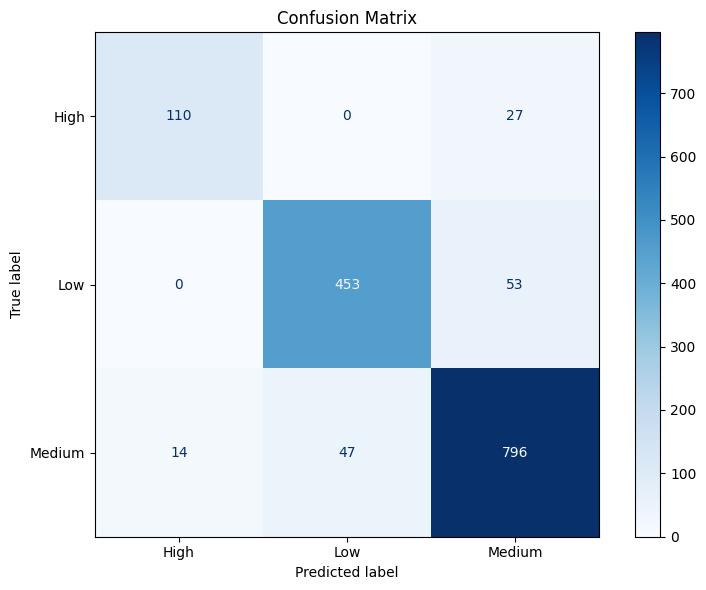

In [66]:
# CONFUSION MATRIX

fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "confusion_matrix.png",
    dpi=300
)

plt.show()

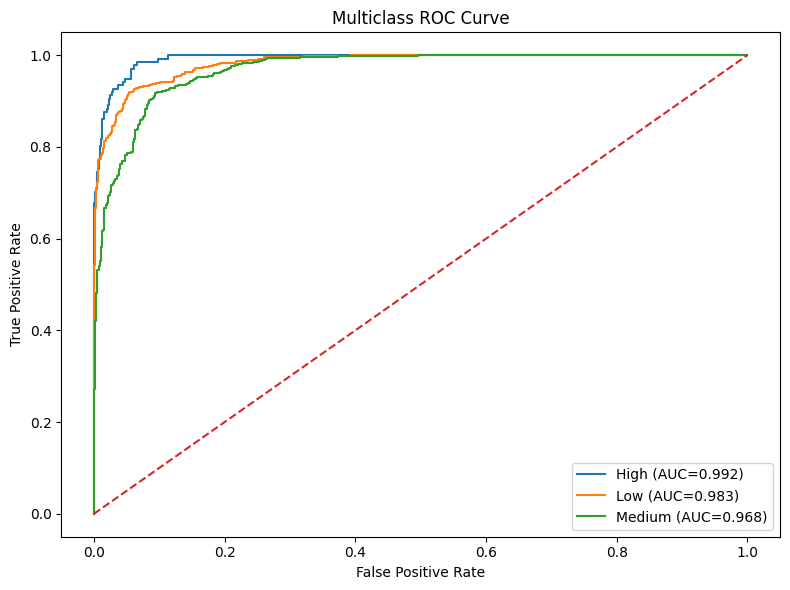

In [67]:
# ROC AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_true)

y_true_bin = label_binarize(
    y_true,
    classes=classes
)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "roc_curve.png",
    dpi=300
)

plt.show()

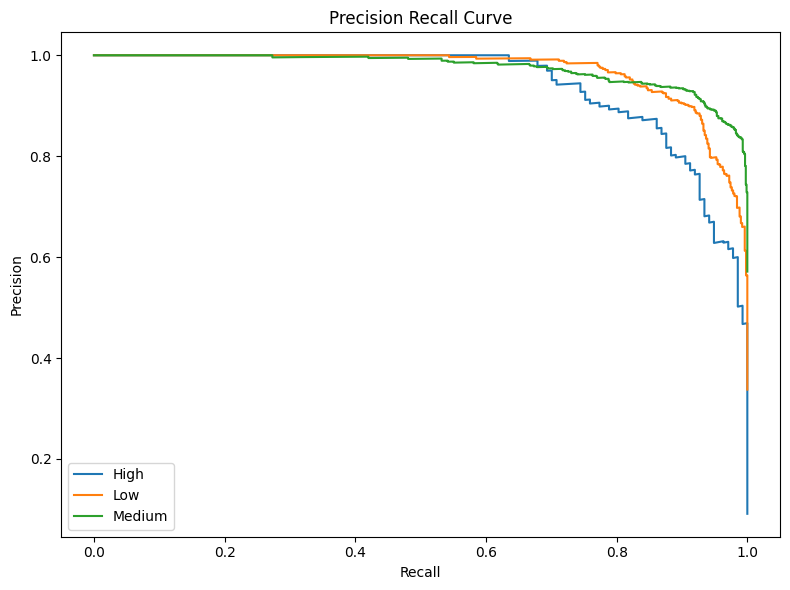

In [68]:
# PRECISION RECALL CURVE

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=label_encoder.classes_[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "precision_recall_curve.png",
    dpi=300
)

plt.show()

<Figure size 700x700 with 0 Axes>

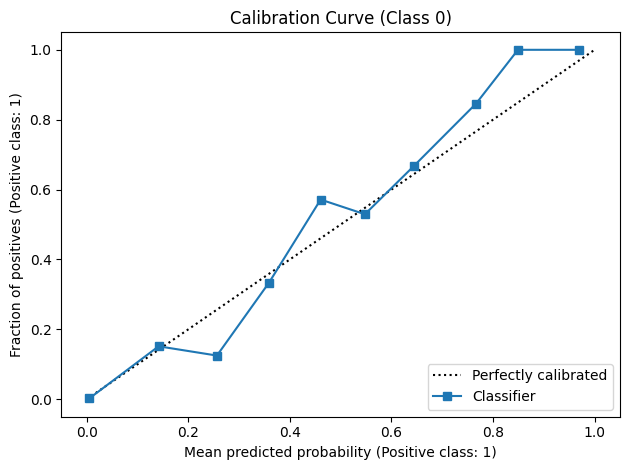

In [69]:
# CALIBRATION CURVE

from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(7,7))

CalibrationDisplay.from_predictions(
    y_true == 0,
    y_prob[:,0],
    n_bins=10
)

plt.title("Calibration Curve (Class 0)")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "calibration_curve.png",
    dpi=300
)

plt.show()

In [70]:
# THRESHOLD ANALYSIS

thresholds = np.arange(
    0.30,
    0.80,
    0.05
)

threshold_df = pd.DataFrame({
    "Threshold": thresholds
})

display(threshold_df)

,Threshold
0,0.30
1,0.35
2,0.40
3,0.45
4,0.50
5,0.55
6,0.60
7,0.65
8,0.70
9,0.75


In [71]:
# ERROR ANALYSIS

prediction_df = X_test.copy()
prediction_df["Actual"] = label_encoder.inverse_transform(y_true)
prediction_df["Prediction"] = label_encoder.inverse_transform(y_pred)

prediction_df["Correct"] = (
    prediction_df["Actual"] == prediction_df["Prediction"]
)

display(
    prediction_df.head()
)

,age_month,gender,birth_weight,birth_length,mother_age,mother_education,mother_working,father_education,father_working,family_income,...,house_density,exclusive_breastfeeding,protein_intake,vitamin_intake,immunization,diarrhea_history,healthcare_access,Actual,Prediction,Correct
0,59,F,2.54,45.8,25.0,higher,1,secondary,1.0,medium,...,low,0.0,medium,medium,complete,0,good,Medium,Medium,True
1,16,F,3.26,48.5,36.0,higher,1,none,1.0,medium,...,low,NaN,high,low,partial,0,poor,Medium,Low,False
2,21,F,3.09,49.0,20.0,primary,0,higher,1.0,low,...,medium,1.0,medium,medium,partial,0,poor,Medium,Medium,True
3,0,F,3.15,47.9,24.0,secondary,1,secondary,1.0,medium,...,low,1.0,low,high,partial,0,fair,Medium,Medium,True
4,45,F,2.72,48.7,33.0,secondary,1,none,1.0,medium,...,medium,1.0,medium,low,complete,0,fair,Medium,Medium,True


In [72]:
# MISCLASSIFIED SAMPLE

misclassified = prediction_df.loc[
    prediction_df["Correct"] == False
]

print(
    "Total Misclassified:",
    len(misclassified)
)

display(
    misclassified.head(20)
)

Total Misclassified: 141


,age_month,gender,birth_weight,birth_length,mother_age,mother_education,mother_working,father_education,father_working,family_income,...,house_density,exclusive_breastfeeding,protein_intake,vitamin_intake,immunization,diarrhea_history,healthcare_access,Actual,Prediction,Correct
1,16,F,3.26,48.5,36.0,higher,1,none,1.0,medium,...,low,NaN,high,low,partial,0,poor,Medium,Low,False
13,13,F,2.58,44.8,32.0,primary,1,secondary,1.0,high,...,low,1.0,high,medium,partial,0,good,Medium,Low,False
18,29,M,3.54,51.5,39.0,higher,1,secondary,1.0,low,...,medium,1.0,high,low,complete,1,good,Medium,Low,False
25,30,F,2.17,48.3,30.0,higher,1,secondary,1.0,medium,...,medium,0.0,high,high,complete,0,good,Medium,Low,False
37,28,F,3.13,49.2,15.0,primary,1,secondary,1.0,medium,...,medium,1.0,medium,high,complete,0,good,Low,Medium,False
43,59,F,3.66,50.2,31.0,primary,0,secondary,1.0,medium,...,low,1.0,medium,low,complete,0,good,Medium,Low,False
49,15,M,2.02,46.5,31.0,higher,1,primary,1.0,medium,...,high,1.0,medium,high,complete,1,fair,High,Medium,False
61,27,M,3.62,53.3,20.0,primary,0,secondary,1.0,medium,...,medium,1.0,low,medium,complete,1,good,High,Medium,False
75,7,F,3.28,51.7,15.0,primary,0,higher,1.0,medium,...,medium,1.0,medium,medium,complete,0,good,Low,Medium,False
80,46,M,3.52,49.3,17.0,secondary,0,primary,1.0,high,...,high,0.0,high,high,complete,0,fair,Medium,Low,False


,Feature,Importance
6,num__clean_water,10.972198
9,num__diarrhea_history,10.916896
25,cat__sanitation_good,8.167445
31,cat__protein_intake_low,7.666794
1,num__birth_weight,7.591081
30,cat__protein_intake_high,5.613589
26,cat__sanitation_poor,5.144113
20,cat__family_income_high,4.781220
36,cat__immunization_complete,4.563116
23,cat__family_income_very_low,4.359219


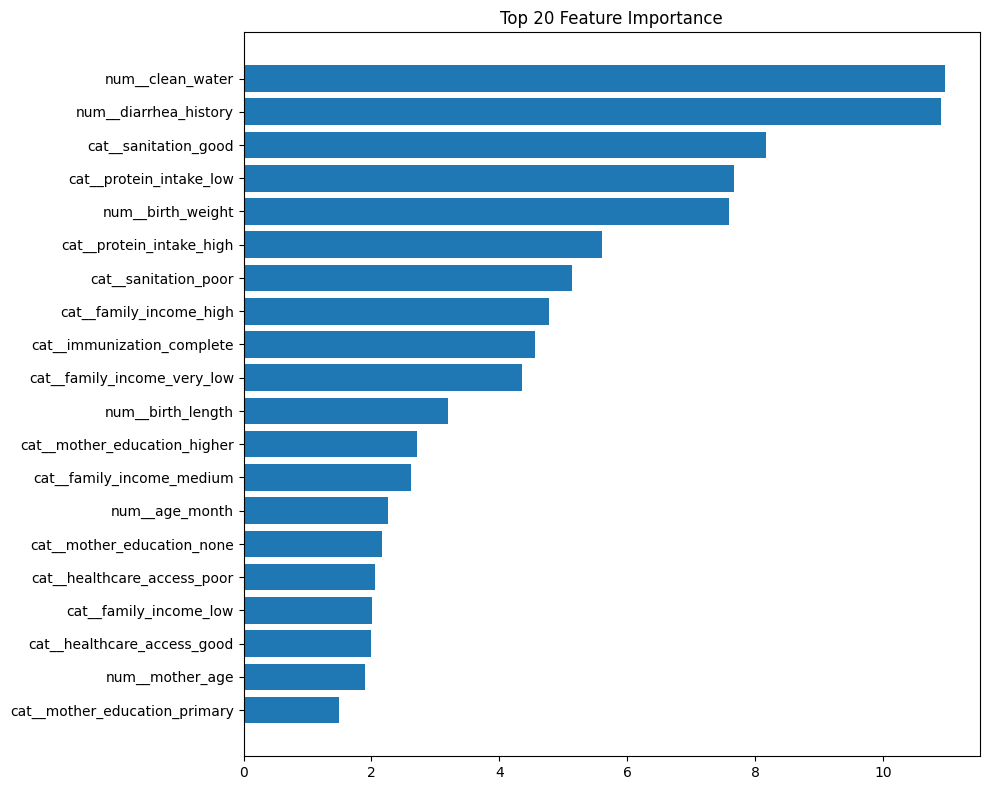

In [73]:
# FEATURE IMPORTANCE

model = best_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    display(
        importance.head(20)
    )

    plt.figure(figsize=(10,8))

    plt.barh(
        importance.head(20)["Feature"][::-1],
        importance.head(20)["Importance"][::-1]
    )

    plt.title("Top 20 Feature Importance")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "feature_importance.png",
        dpi=300
    )

    plt.show()

else:
    print("Feature importance is not available for this model.")

In [74]:
# SAVE METRICS

with open(
    METRIC_DIR / "metrics.json",
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )
report_df.to_json(
    METRIC_DIR / "classification_report.json",
    indent=4
)

print("Metrics saved.")

Metrics saved.


# Save Artifacts

Tahap ini menyimpan seluruh artifact yang diperlukan oleh backend.

Backend nantinya cukup melakukan:

- Load Pipeline
- Predict
- Return Response

tanpa preprocessing tambahan.

In [75]:
# SAVE TRAINED PIPELINE

pipeline_path = TRAINED_MODEL_DIR / "best_pipeline.pkl"

joblib.dump(
    best_pipeline,
    pipeline_path
)

print(f"Pipeline saved to:\n{pipeline_path}")

Pipeline saved to:
/kaggle/working/model/trained_models/best_pipeline.pkl


In [76]:
# SAVE LABEL ENCODER

label_encoder_path = ARTIFACT_DIR / "label_encoder.pkl"

joblib.dump(
    label_encoder,
    label_encoder_path
)

print(f"Label Encoder saved to:\n{label_encoder_path}")

Label Encoder saved to:
/kaggle/working/model/artifacts/label_encoder.pkl


In [77]:
# SAVE FEATURE NAMES

feature_names_path = ARTIFACT_DIR / "feature_names.json"

with open(
    feature_names_path,
    "w"
) as f:

    json.dump(
        feature_names.tolist(),
        f,
        indent=4
    )

print("Feature names saved.")

Feature names saved.


In [78]:
# SAVE LABEL MAPPING

label_mapping_path = ARTIFACT_DIR / "label_mapping.json"

with open(
    label_mapping_path,
    "w"
) as f:

    json.dump(
        label_mapping,
        f,
        indent=4
    )

print("Label mapping saved.")

Label mapping saved.


In [80]:
# SAVE TRAINING CONFIG

training_config = {
    "random_state": RANDOM_STATE,
    "target_column": TARGET_COLUMN,
    "cross_validation": N_SPLITS,
    "best_model": best_model_name,
    "scoring_metric": "f1_weighted"
}

config_path = ARTIFACT_DIR / "training_config.json"

with open(
    config_path,
    "w"
) as f:
    json.dump(
        training_config,
        f,
        indent=4
    )

print("Training config saved.")

Training config saved.


In [81]:
# SAVE MODEL INFO

model_info = {
    "model_name": best_model_name,
    "train_samples": int(len(X_final_train)),
    "test_samples": int(len(X_test)),
    "original_features": int(X_train.shape[1]),
    "processed_features": int(len(feature_names)),
    "classes": label_encoder.classes_.tolist()
}

with open(
    METRIC_DIR / "model_info.json",
    "w"
) as f:
    json.dump(
        model_info,
        f,
        indent=4
    )

print("Model information saved.")

Model information saved.


# Backend Compatibility Check

Tahap ini mensimulasikan bagaimana FastAPI akan menggunakan model.

Backend hanya perlu:

- load pipeline
- predict
- predict_proba

Tidak diperlukan preprocessing manual.

In [82]:
# LOAD PIPELINE

loaded_pipeline = joblib.load(
    pipeline_path
)

loaded_encoder = joblib.load(
    label_encoder_path
)

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


In [83]:
# SAMPLE INFERENCE

sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample)
probability = loaded_pipeline.predict_proba(sample)
prediction_label = loaded_encoder.inverse_transform(
    prediction
)

print("Prediction :", prediction_label[0])
print("\nProbability")

prob_df = pd.DataFrame({
    "Class": loaded_encoder.classes_,
    "Probability": probability[0]
})

display(prob_df)

Prediction : Medium

Probability


,Class,Probability
0,High,0.000305
1,Low,0.168276
2,Medium,0.831419


In [84]:
# BATCH INFERENCE

batch = X_test.iloc[:5]
pred = loaded_pipeline.predict(batch)
pred = loaded_encoder.inverse_transform(pred)

display(pd.DataFrame({
    "Prediction": pred
}))

,Prediction
0,Medium
1,Low
2,Medium
3,Medium
4,Medium


In [85]:
# PIPELINE VALIDATION

assert hasattr(
    loaded_pipeline,
    "predict"
)

assert hasattr(
    loaded_pipeline,
    "predict_proba"
)

print("Pipeline verification passed.")

Pipeline verification passed.


# Summary

Notebook telah berhasil membangun pipeline Machine Learning secara lengkap mulai dari pemuatan dataset hingga penyimpanan artifact yang siap digunakan pada backend FastAPI.

Seluruh preprocessing telah terintegrasi di dalam pipeline sehingga backend tidak memerlukan proses tambahan sebelum melakukan prediksi.

In [86]:
# FINAL SUMMARY

summary = pd.DataFrame({

    "Item":[
        "Best Model",
        "Training Samples",
        "Testing Samples",
        "Original Features",
        "Processed Features",
        "Number of Classes",
        "Cross Validation Folds"

    ],

    "Value":[
        best_model_name,
        len(X_final_train),
        len(X_test),
        X_train.shape[1],
        len(feature_names),
        len(label_encoder.classes_),
        N_SPLITS
    ]

})

display(summary)

,Item,Value
0,Best Model,CatBoost
1,Training Samples,8500
2,Testing Samples,1500
3,Original Features,20
4,Processed Features,42
5,Number of Classes,3
6,Cross Validation Folds,5


In [87]:
# GENERATED FILES

print("="*70)
print("TRAINED MODEL")
print("="*70)

for file in TRAINED_MODEL_DIR.glob("*"):
    print(file.name)

print()

print("="*70)
print("ARTIFACTS")
print("="*70)

for file in ARTIFACT_DIR.glob("*"):
    print(file.name)

print()

print("="*70)
print("METRICS")
print("="*70)

for file in METRIC_DIR.glob("*"):
    print(file.name)

print()

print("="*70)
print("FIGURES")
print("="*70)

for file in FIGURE_DIR.glob("*"):
    print(file.name)

TRAINED MODEL
best_pipeline.pkl

ARTIFACTS
feature_names.json
label_encoder.pkl
training_config.json
label_mapping.json

METRICS
classification_report.json
cross_validation.json
model_info.json
metrics.json

FIGURES
calibration_curve.png
roc_curve.png
precision_recall_curve.png
feature_importance.png
confusion_matrix.png


In [88]:
import shutil

shutil.make_archive('model_output', 'zip', '/kaggle/working/model')

print("Folder model berhasil di-zip dan siap di-download!")

Folder model berhasil di-zip dan siap di-download!


## Final Step: Download Model Artifacts

Seluruh artifact model (termasuk *pipeline* terbaik, *label encoder*, *metrics*, dan visualisasi) telah tersimpan dengan rapi di dalam folder `model`. 

Script di bawah ini akan mengompres folder tersebut menjadi file **`model_output.zip`** agar mudah diunduh.

**Cara Download:**
1. Perhatikan panel **Output** di sebelah kanan layar (pada direktori `/kaggle/working`).
2. Jika file belum muncul, klik ikon *Refresh/Directory Sync*.
3. Klik ikon titik tiga (⋮) pada file `model_output.zip`, lalu pilih **Download**.

---
*Pipeline Machine Learning untuk Prediksi Risiko Stunting kini telah selesai dan siap untuk diintegrasikan dengan backend FastAPI*